<a href="https://colab.research.google.com/github/ahmed3499999/dl-project/blob/master/train_model_finish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip it to Colab
!unzip "/content/drive/MyDrive/GTSRB_restructured.zip" -d "/content"



Streaming output truncated to the last 5000 lines.
 extracting: /content/fGTSRB_restructured/Test/1/09037.png  
 extracting: /content/fGTSRB_restructured/Test/1/11065.png  
 extracting: /content/fGTSRB_restructured/Test/1/10513.png  
 extracting: /content/fGTSRB_restructured/Test/1/01001.png  
 extracting: /content/fGTSRB_restructured/Test/1/07945.png  
 extracting: /content/fGTSRB_restructured/Test/1/00546.png  
 extracting: /content/fGTSRB_restructured/Test/1/06855.png  
 extracting: /content/fGTSRB_restructured/Test/1/00175.png  
 extracting: /content/fGTSRB_restructured/Test/1/03132.png  
 extracting: /content/fGTSRB_restructured/Test/1/11098.png  
 extracting: /content/fGTSRB_restructured/Test/1/07999.png  
 extracting: /content/fGTSRB_restructured/Test/1/03153.png  
 extracting: /content/fGTSRB_restructured/Test/1/07533.png  
 extracting: /content/fGTSRB_restructured/Test/1/03408.png  
 extracting: /content/fGTSRB_restructured/Test/1/05373.png  
 extracting: /content/fGTSRB_restr

In [ ]:
train_dir = "/content/fGTSRB_restructured/Train"
test_dir = "/content/fGTSRB_restructured/Test"


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
batch_size = 64
image_size = (48, 48)

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    # transforms.RandomRotation(10),
    # transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214], std=[0.2724, 0.2608, 0.2669])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.3403, 0.3121, 0.3214], std=[0.2724, 0.2608, 0.2669])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print('Train samples:', len(train_dataset))
print('Test samples:', len(test_dataset))
print('Classes:', train_dataset.classes)

Train samples: 39209
Test samples: 12630
Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [ ]:
print(train_dataset.classes)


['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']


In [ ]:
class GTSRBCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

num_classes = 43
model = GTSRBCNN(num_classes).to(device)
print(model)

GTSRBCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU()
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inplac

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [ ]:
from tqdm.notebook import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
        pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100*correct/total:.2f}'})
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='Eval', leave=False)
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            pbar.set_postfix({'loss': f'{running_loss/total:.4f}', 'acc': f'{100*correct/total:.2f}'})
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
num_epochs = 30
best_acc = 0.0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(1, num_epochs+1):
    print(f'----- Epoch {epoch}/{num_epochs} -----')
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step(val_acc)
    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
    print(f'Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%')
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'gtsrb_cnn_best.pth')
        print('Saved best model, val acc:', best_acc)

----- Epoch 1/30 -----


Train:   0%|          | 0/613 [00:00<?, ?it/s]

Eval:   0%|          | 0/198 [00:00<?, ?it/s]

Train Loss: 0.5544 Acc: 84.91% | Val Loss: 0.1695 Acc: 96.70%
Saved best model, val acc: 0.9669833729216152
----- Epoch 2/30 -----


Train:   0%|          | 0/613 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/198 [00:00<?, ?it/s]

Train Loss: 0.0008 Acc: 99.97% | Val Loss: 0.2044 Acc: 98.58%
----- Epoch 30/30 -----


Train:   0%|          | 0/613 [00:00<?, ?it/s]

Eval:   0%|          | 0/198 [00:00<?, ?it/s]

Train Loss: 0.0010 Acc: 99.97% | Val Loss: 0.3110 Acc: 98.26%


In [ ]:
# Label Overview
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }

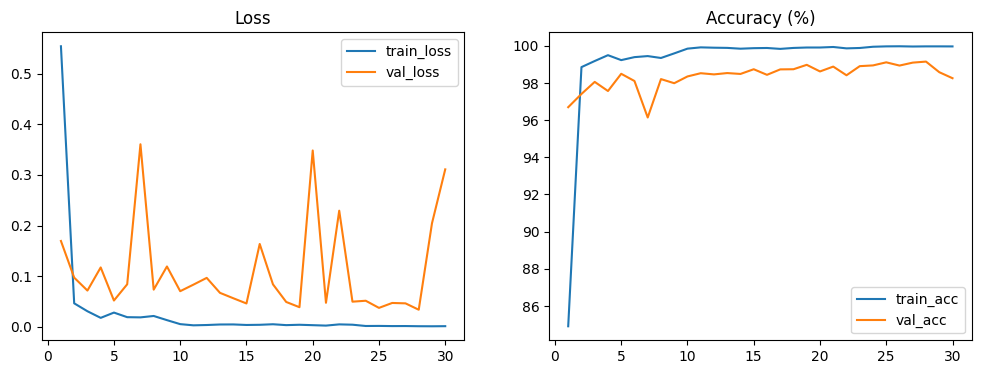

In [ ]:
import matplotlib.pyplot as plt
if history['train_loss']:
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(epochs, [h*100 for h in history['train_acc']], label='train_acc')
    plt.plot(epochs, [h*100 for h in history['val_acc']], label='val_acc')
    plt.legend(); plt.title('Accuracy (%)')
    plt.show()

Confusion Matrix shape: (43, 43)


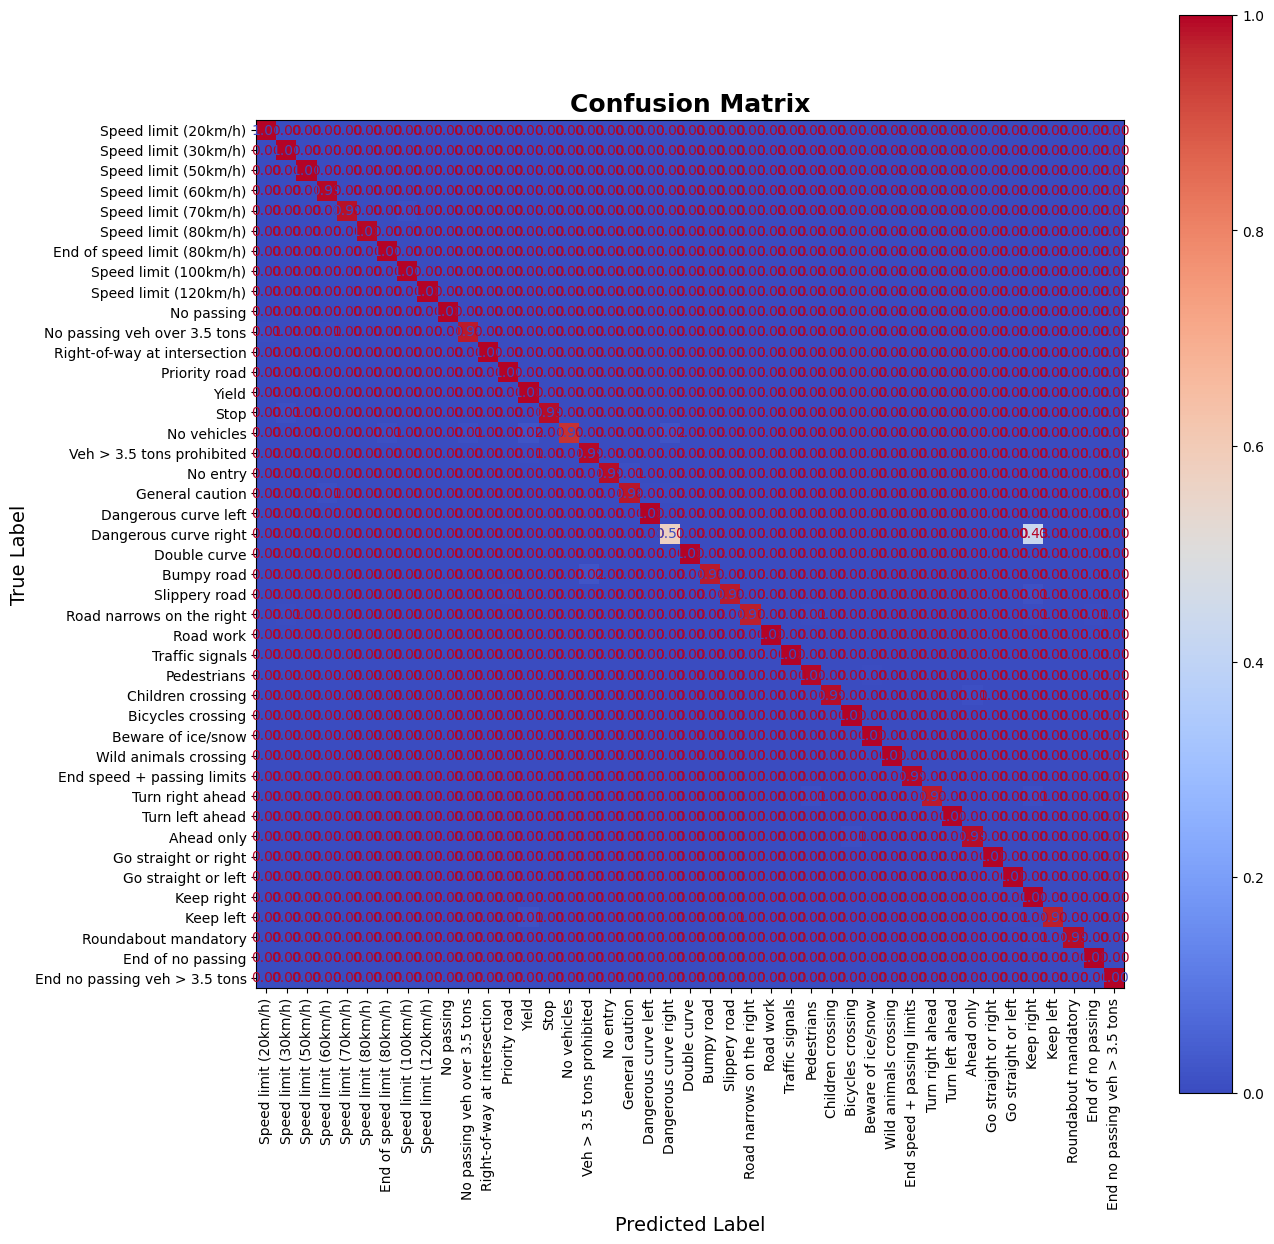

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix shape:", cm.shape)

# Normalize for better visual balance (optional)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create the plot
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=list(classes.values()))
disp.plot(cmap="coolwarm", ax=ax, colorbar=True, xticks_rotation=90, values_format=".2f")

# Customize titles and fonts
plt.title("Confusion Matrix", fontsize=18, weight='bold')
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(False)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(classes.values())))


Classification Report:
                               precision    recall  f1-score   support

         Speed limit (20km/h)       0.97      1.00      0.98        60
         Speed limit (30km/h)       0.99      1.00      1.00       720
         Speed limit (50km/h)       1.00      1.00      1.00       660
         Speed limit (60km/h)       0.98      0.99      0.99       420
         Speed limit (70km/h)       1.00      0.99      0.99       690
         Speed limit (80km/h)       1.00      1.00      1.00       720
  End of speed limit (80km/h)       0.99      1.00      1.00       270
        Speed limit (100km/h)       0.97      1.00      0.98       210
        Speed limit (120km/h)       1.00      1.00      1.00       150
                   No passing       1.00      1.00      1.00       360
 No passing veh over 3.5 tons       0.99      0.98      0.99       390
 Right-of-way at intersection       1.00      1.00      1.00        60
                Priority road       0.99      1.00   